# Cell TV - whoop whoop
This script showcases a bunch of functions that each show a characteristic feature for a cell in a given recording session to get the best overview possible of what this cell is doing. 

The script will receive mouse, session, basepath info and a cell number. It will show:
- mean registered image with selected cell outline
- crop out of mean registered image with just that cell
- full df/f trace, with rewards/position highlighted by vertical lines
- heatmap of reward PSTH trials 
- mean +- SEM of reward psth (with lick rate and average position change in grey underneath)
- mean +- SEM of 10 (or less) landmark PSTHs
- speed tuning
- position binned activity 
- latent structure split of position plots
- goal progress polar plot
- correlation of cell trace with all other cells

It does not cover population level analyses: put into a separate script
- decoding of specific variables from the whole population (position, goal progress, task state, latent state)


In [1]:
import os
import sys
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from scipy.signal import find_peaks
from barcode import barcode_util
from barcode import extract_barcodes
import pickle
import parse_session_functions
from suite2p.extraction import dcnv
import scipy.stats as stats
from scipy.ndimage import gaussian_filter1d
import matplotlib.patches as patches
import cellTV_functions as cellTV
imp.reload(cellTV)
#suppress the warnings
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

## Provide mouse and session information

In [2]:
mouse = 'TAA0000066'
stage = '-t6'
base_path = '/Volumes/mrsic_flogel/public/projects/AtApSuKuSaRe_20250129_HFScohort2/'
imaging_path, config_path, frame_ix, date1, date2 = cellTV.get_session_folders(base_path, mouse, stage)

## Extract neural and behavioural data

In [3]:
f, fneu, iscell, ops, seg, frame_rate = cellTV.load_img_data(imaging_path)
dF = cellTV.get_dff(f, fneu, frame_ix, ops)

Calculated dF/F with the following parameters: baseline=maximin, win_baseline=60.0, sig_baseline=10.0, fs=45,perctile_baseline=8.0


In [4]:
if stage in ['-t3','-t4','-t5', '-t6']:
    session = parse_session_functions.analyse_npz_pre7(mouse, date2, plot=False)
else:
    session = parse_session_functions.analyse_npz(mouse,date2,plot=True)

Training and Imaging
Number of laps: 1
Number of landmarks: 443
Updated number of laps: 45
Updated positions, landmarks and goals for pre-7 sessions
New landmarks: [[  0  16]
 [ 27  43]
 [ 54  70]
 [ 81  97]
 [108 124]
 [135 151]
 [162 178]
 [189 205]
 [216 232]
 [243 259]]
New goals: [[ 27  43]
 [ 81  97]
 [135 151]
 [189 205]]
Number of laps =  45


## Select a cell and display its mean fluorescence and segmentation

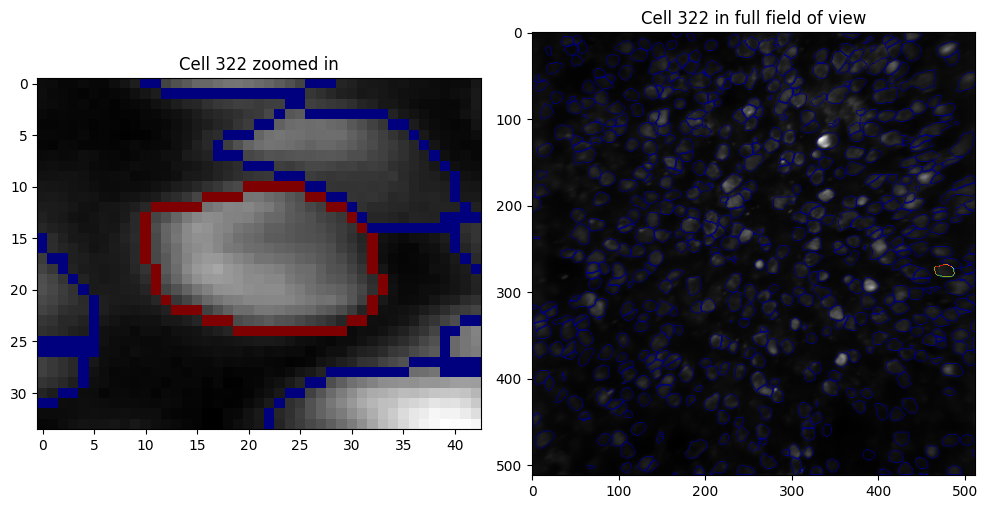

In [59]:
cell = 322
cellTV.show_cell_fov(cell,ops,seg)

Get the trace for this cell and plot the full trace + position + reward + LM info

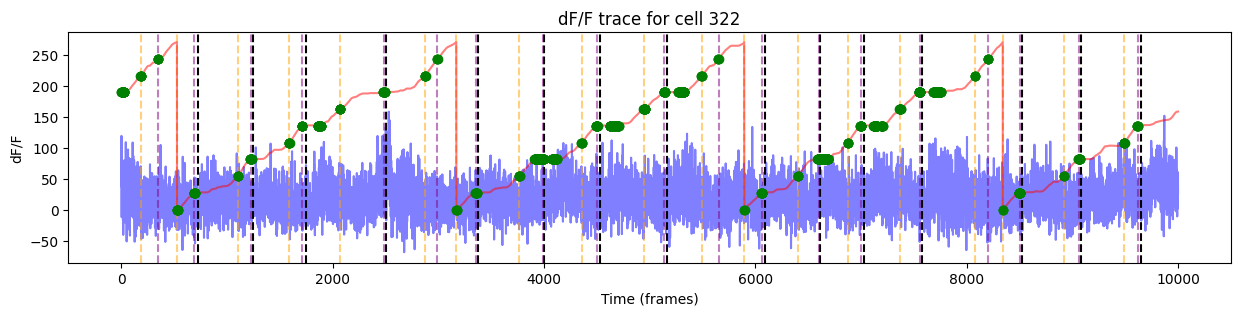

In [60]:
dF_cell = cellTV.extract_cell_trace(dF,cell,plot=True,session=session,frame_range=[10000,20000])

## Basic tuning properties

### Reward tuning

Number of rewards: 178
Number of outliers: 0
Number of rewards after removing outliers: 178
ignoring last reward,too close to end of session
ignoring last reward,too close to end of session


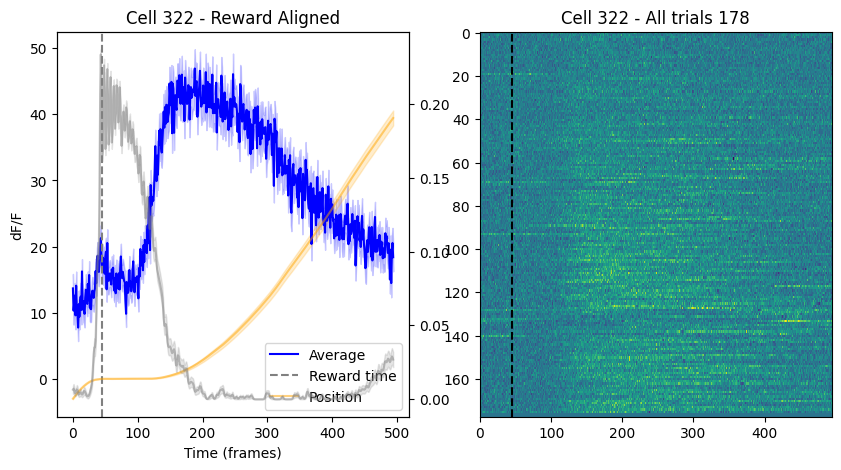

In [61]:
cell_rewards = cellTV.extract_reward_tuning(dF, cell, session, frame_rate=45 ,window_size = [-1,10], plot=True)

### Position tuning
Heads up: Position analysis makes no sense in pseudorandom corridors (like t3 and t4), ignore that for these sessions

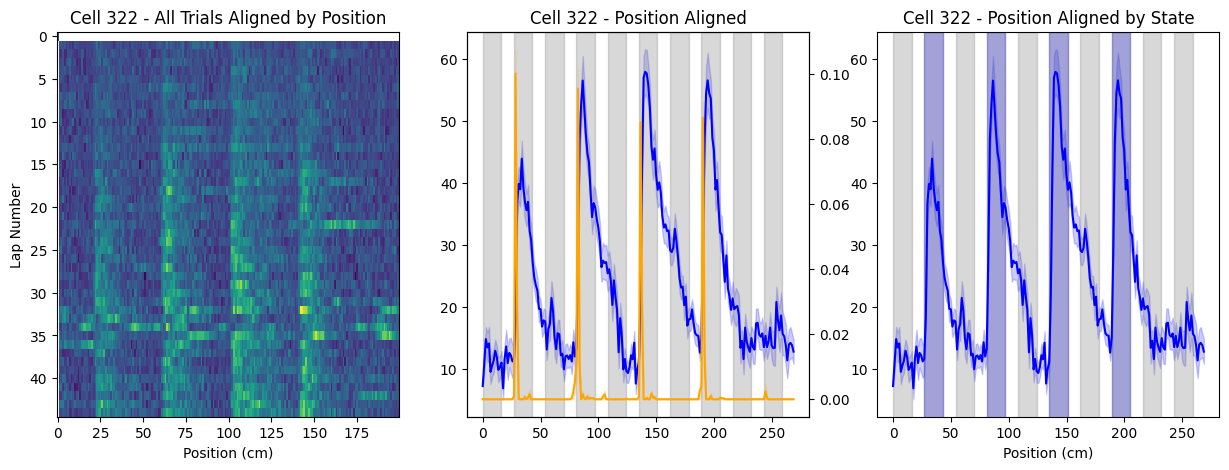

In [62]:
fr_per_bin, bin_edges = cellTV.extract_position_tuning(dF, cell, stage, session, frame_rate=45, bins=200, plot=True)

### Landmark tuning (frame window around LM entry based on position)

Landmark 0 not found in lap 1
Landmark 27 not found in lap 1
Landmark 54 not found in lap 1
Landmark 81 not found in lap 1
Landmark 108 not found in lap 1
Landmark 135 not found in lap 1
Landmark 162 not found in lap 1
Landmark 189 not found in lap 1
Landmark 216 not found in lap 1
Landmark 243 not found in lap 1


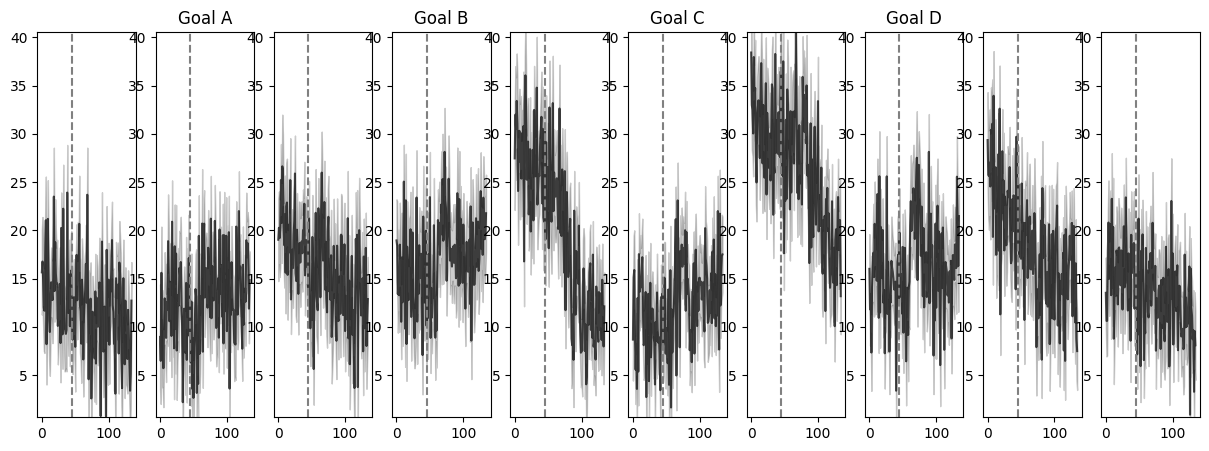

In [63]:
landmark_frames, lm_entries = cellTV.extract_lm_tuning(dF, cell, session, stage, frame_rate=45, window_size=[-1, 2], plot=True)

### Goal progress tuning
Based on reward indices (binned by time in between)

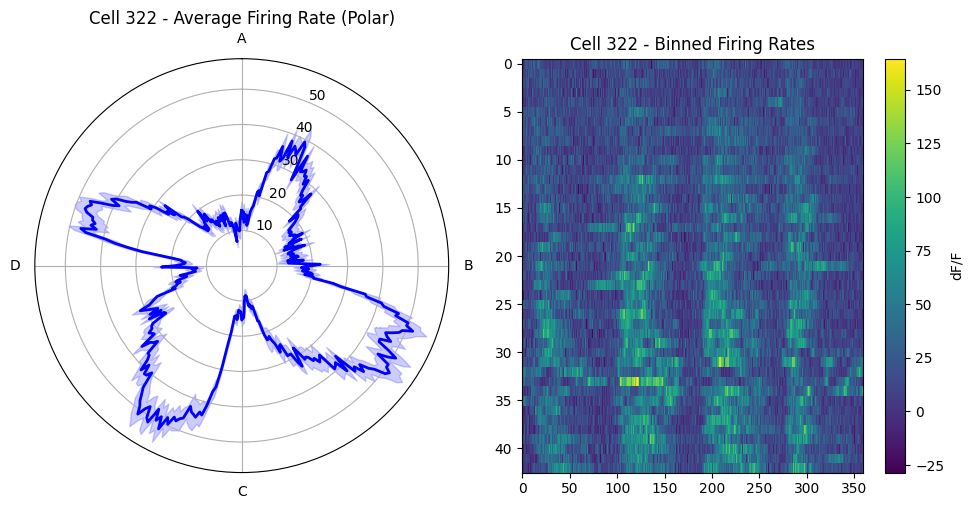

In [64]:
binned_all, reward_ix = cellTV.extract_goal_progress(dF,cell,session,frame_rate = 45,bins=90,plot=True,shuffle=False)

Alternatively, 'goal'-progress can be calculated based on any event indices and with respect to any number of goals. If you supply reward indices and n-goals = 4, this function is identical to the above.

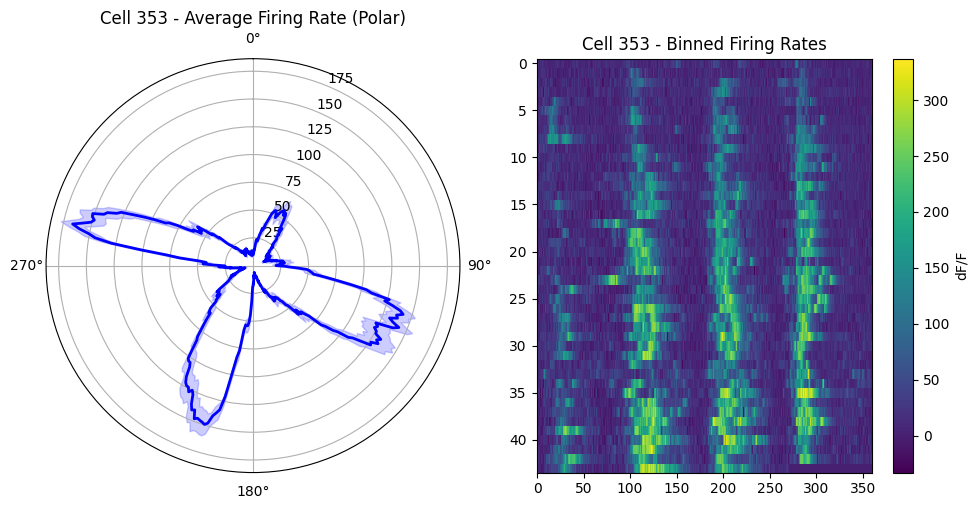

In [51]:
binned_all = cellTV.extract_arb_progress(dF, cell, reward_ix, 4, 90, plot=True,shuffle=False)

One way of quantifying goal tuning is to calculate the max/min/mean activity in any phase and do max-min/mean and compare this to a shuffle distribution (shuffle activity per trial across phase bins).

Real score for cell 353 is 2.35, phase preference is 20.00, state preference is 3.00
P-value for cell 353 is 0.00000000


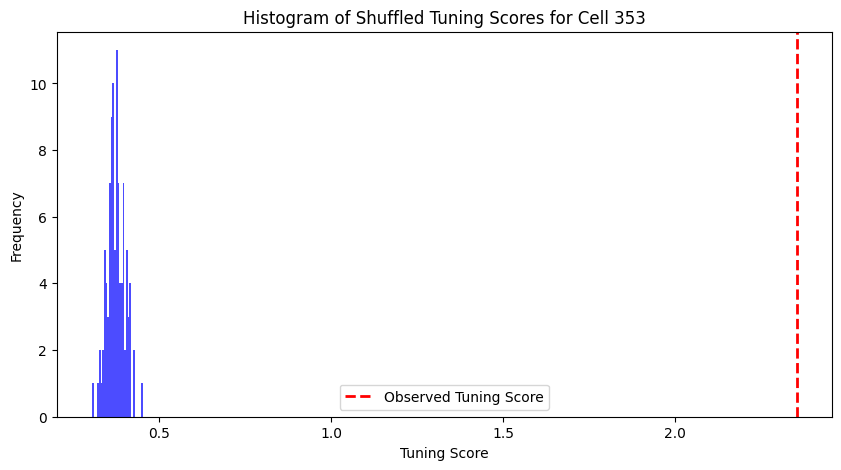

In [52]:
real_score,shuffled_scores,phase_pref,state_pref = cellTV.calc_goal_tuningix(dF, cell, session, condition='goal',event_frames=None,n_goals=4, frame_rate=45, bins=90,shuffle=True, plot=True)

In [ ]:
#bin goal progress by position instead of time

Example of alternative 'goal'-progress calculation based on licked landmarks (i.e. sth like internal goals). The same tuning index calculation as above can be done.

Found 178 first licks in the session
First licks first lap: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
First licks flattened: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


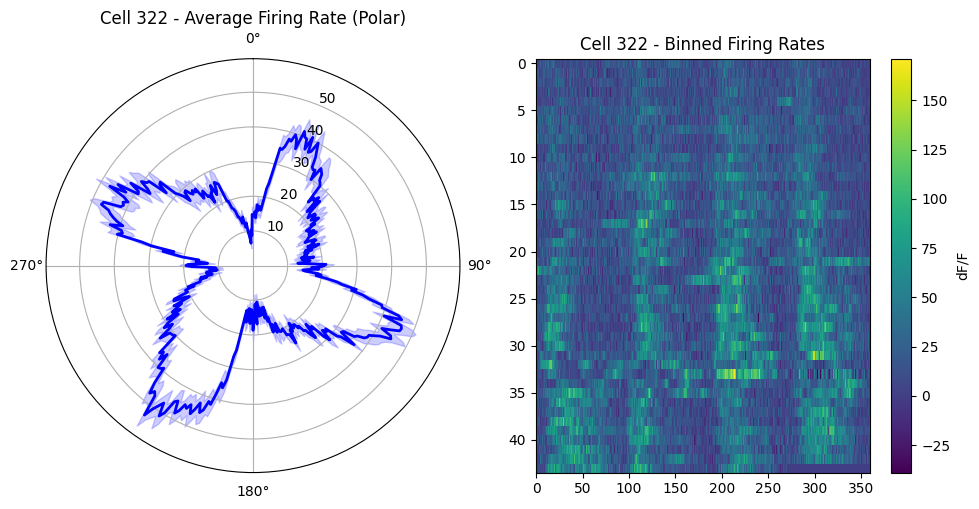

In [65]:
#look for internal goal progress by considering each licked landmark as a goal (regardless of reward)
lick_frames, lin_first_licks = cellTV.extract_lick_tuning(dF, cell, session, frame_rate=45, window_size=[-1,5], plot=False)
lin_first_licks = np.delete(lin_first_licks, np.where(lin_first_licks < 0)[0])  # Remove negative values (i.e. no lick in LM)
binned_all = cellTV.extract_arb_progress(dF, cell, lin_first_licks, 4, 90, plot=True)

### Speed tuning (speed bins)

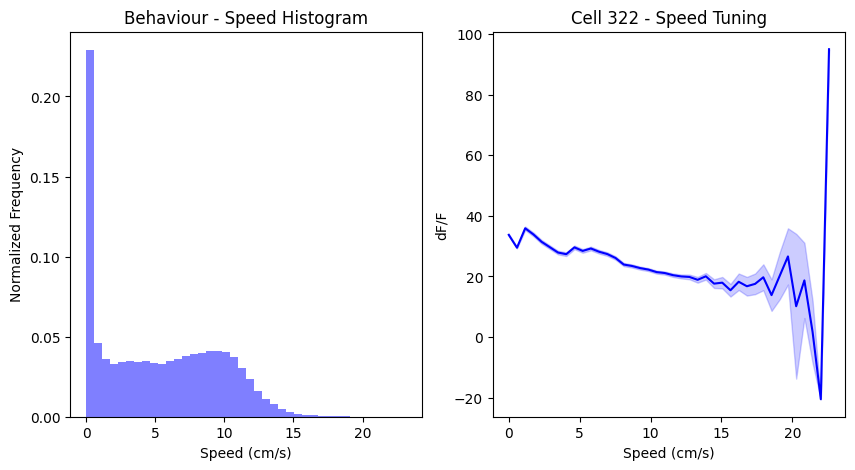

In [66]:
fr_per_spbin, speed_hist,speed_edges = cellTV.extract_speed_tuning(dF, cell, session, bins=40, plot=True)

### Lick tuning (only taking first licks per LM to account for lick bouts and reward consumption)

Found 178 first licks in the session
First licks first lap: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]
First licks flattened: [-1 -1 -1 -1 -1 -1 -1 -1 -1 -1]


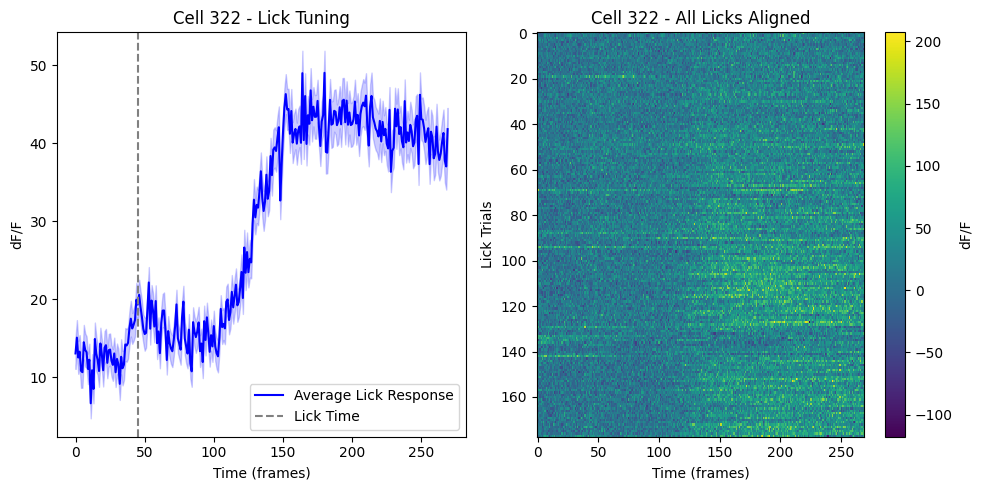

In [67]:
lick_frames, lin_first_licks = cellTV.extract_lick_tuning(dF, cell, session, frame_rate=45, window_size=[-1,5], plot=True)

### Peri-event time histograms to any arbitrary events 
This function is identical to extracting reward or lick tuning if supplied with reward/lick indices, but can be used for subsampling or other arbitrary event analyses

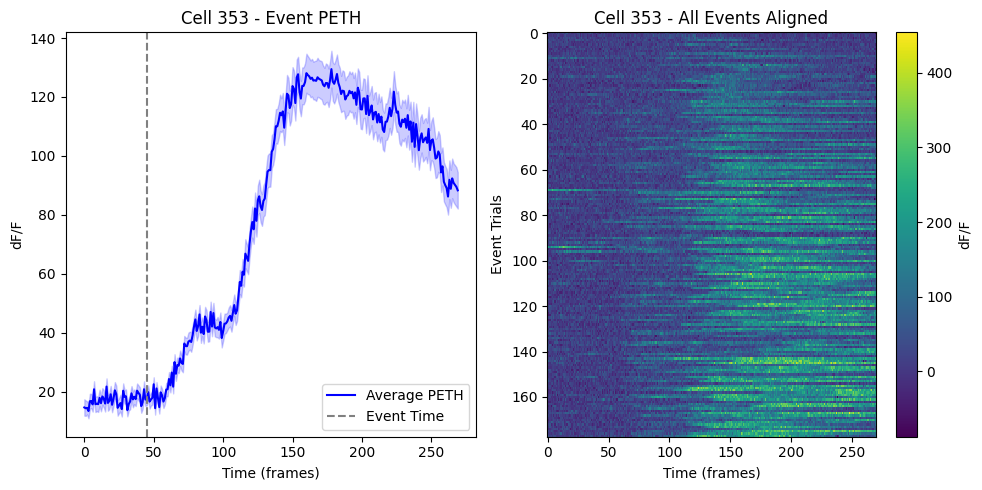

In [57]:
peth_frames = cellTV.extract_arb_peth(dF,cell,lin_first_licks, frame_rate=45, window_size=[-1,5], plot=True)

### Cell's correlation with all other cells in that FOV

Top 5 correlated cells: [ 47 415 493 322 353], correlations: [0.23850885 0.30866159 0.3087484  0.31140388 1.        ]
Bottom 5 correlated cells: [ 42 115 110 371 101], correlations: [-0.26671819 -0.16208484 -0.14353019 -0.14190998 -0.10944469]


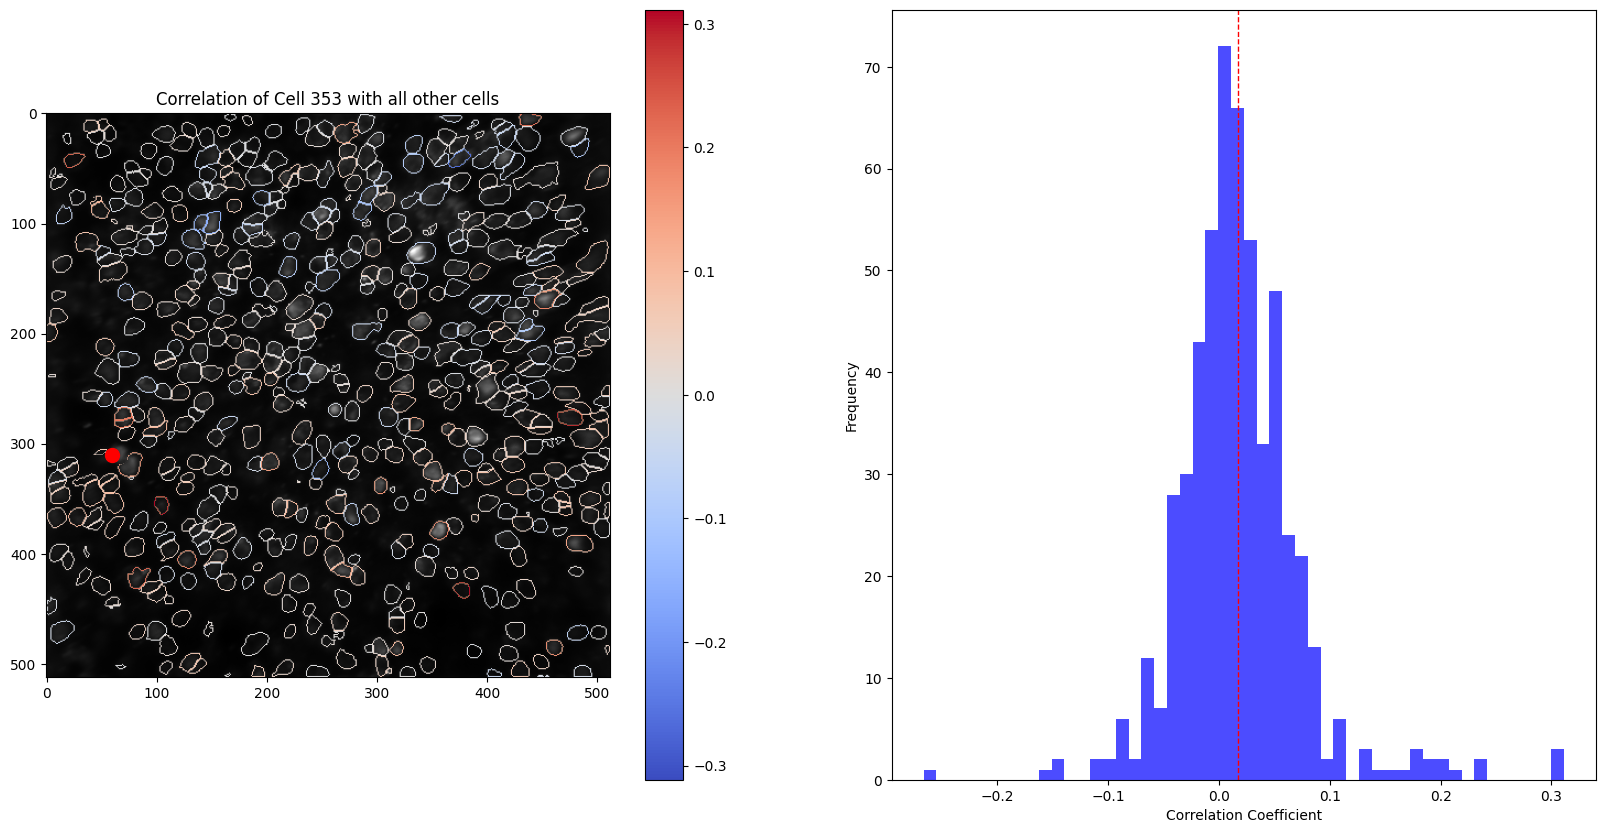

In [58]:
cellTV.extract_cell_correlation(dF, cell, ops, seg, session=None, plot=True)